# Flight Delay Analytics Using Python
### Sprint 3: Advanced Statistics & Feature Engineering
Name: N. Yuvaraj  
Batch: 544-A  
Dataset: Flight_Delays_Cleaned_v2.csv

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
df = pd.read_csv("Flight_Delays_Cleaned_v2.csv")

In [11]:
df.shape

(50000, 30)

In [12]:
df.head()

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
0,2015-05-14,May,Thursday,US,1721,N174US,CLT,SMF,18:10:00,18:30:00,...,20:43:00,4.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
1,2015-11-29,November,Sunday,MQ,3363,N902MQ,LEX,ORD,18:37:00,19:06:00,...,19:42:00,17.0,0,0,Not Cancelled,0.0,0.0,0.0,17.0,0.0
2,2015-02-10,February,Tuesday,US,1933,N562UW,PHL,ORD,07:30:00,07:25:00,...,08:34:00,-28.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
3,2015-12-21,December,Monday,UA,1929,N460UA,SEA,EWR,06:22:00,06:23:00,...,14:14:00,-17.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
4,2015-05-07,May,Thursday,DL,1478,N67171,ATL,PHL,07:25:00,07:28:00,...,09:20:00,-5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0


## 1. Statistical Analysis

### Measures of Central Tendency and Dispersion

In [13]:
#basic descriptive stats for the important numerical columns
num_cols = ["arrival_delay", "departure_delay", "taxi_out", "taxi_in", "distance", "air_time"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
arrival_delay,49085.0,3.999450,37.754980,-70.0,-13.0,-5.0,8.0,1574.0
departure_delay,49234.0,9.086526,35.464728,-55.0,-5.0,-2.0,7.0,1515.0
taxi_out,49215.0,16.019344,8.805555,1.0,11.0,14.0,19.0,149.0
taxi_in,49182.0,7.406043,5.611428,1.0,4.0,6.0,9.0,165.0
distance,50000.0,824.202920,611.888335,31.0,373.0,646.0,1066.0,4983.0
air_time,49085.0,113.813589,72.559381,9.0,61.0,94.0,144.0,654.0


In [14]:
#mean, median and mode for arrival_delay
mean_arr = df["arrival_delay"].mean()
median_arr = df["arrival_delay"].median()
mode_arr = df["arrival_delay"].mode()[0]

print("Mean:", mean_arr)
print("Median:", median_arr)
print("Mode:", mode_arr)

Mean: 3.9994499337883265
Median: -5.0
Mode: -10.0


In [15]:
#measures of dispersion for arrival_delay
std_arr = df["arrival_delay"].std()
var_arr = df["arrival_delay"].var()
range_arr = df["arrival_delay"].max() - df["arrival_delay"].min()

print("Std Dev:", std_arr)
print("Variance:", var_arr)
print("Range:", range_arr)

Std Dev: 37.75497970987085
Variance: 1425.4384928927598
Range: 1644.0


### Distribution Analysis (Skewness & Kurtosis)

In [16]:
#checking the skewness and kurtosis of the delay columns
for col in ["arrival_delay", "departure_delay", "taxi_out", "taxi_in"]:
    print(col, "-> skew:", round(df[col].skew(),2), " kurtosis:", round(df[col].kurt(),2))

arrival_delay -> skew: 6.39  kurtosis: 109.38
departure_delay -> skew: 7.27  kurtosis: 125.86
taxi_out -> skew: 3.39  kurtosis: 23.0
taxi_in -> skew: 5.42  kurtosis: 67.91


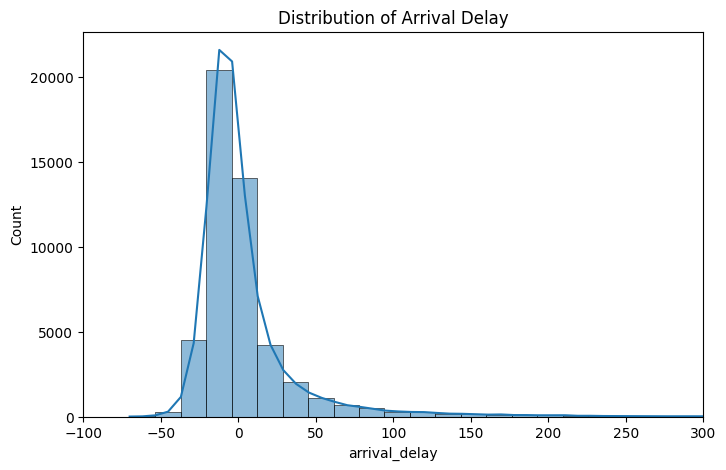

In [17]:
#visualizing the distribution of arrival_delay
plt.figure(figsize=(8,5))
sns.histplot(df["arrival_delay"], bins=100, kde=True)
plt.title("Distribution of Arrival Delay")
plt.xlim(-100, 300)
plt.show()

**Observation:** arrival_delay is highly right-skewed (skew ~6.39). Most flights have a small negative or near-zero delay but a few flights have very large delays which pull the mean above the median. This is why median is used as the typical value and mean is used to understand total impact.

### Correlation and Covariance

In [18]:
#correlation of arrival_delay with other numeric columns
corr_cols = ["arrival_delay","departure_delay","taxi_out","taxi_in","distance","air_time",
             "air_system_delay","security_delay","airline_delay","late_aircraft_delay","weather_delay"]

corr_matrix = df[corr_cols].corr()
corr_matrix["arrival_delay"].sort_values(ascending=False)

arrival_delay          1.000000
departure_delay        0.940819
late_aircraft_delay    0.623057
airline_delay          0.620486
air_system_delay       0.433904
weather_delay          0.277813
taxi_out               0.236572
taxi_in                0.107612
security_delay         0.024830
air_time              -0.008189
distance              -0.027972
Name: arrival_delay, dtype: float64

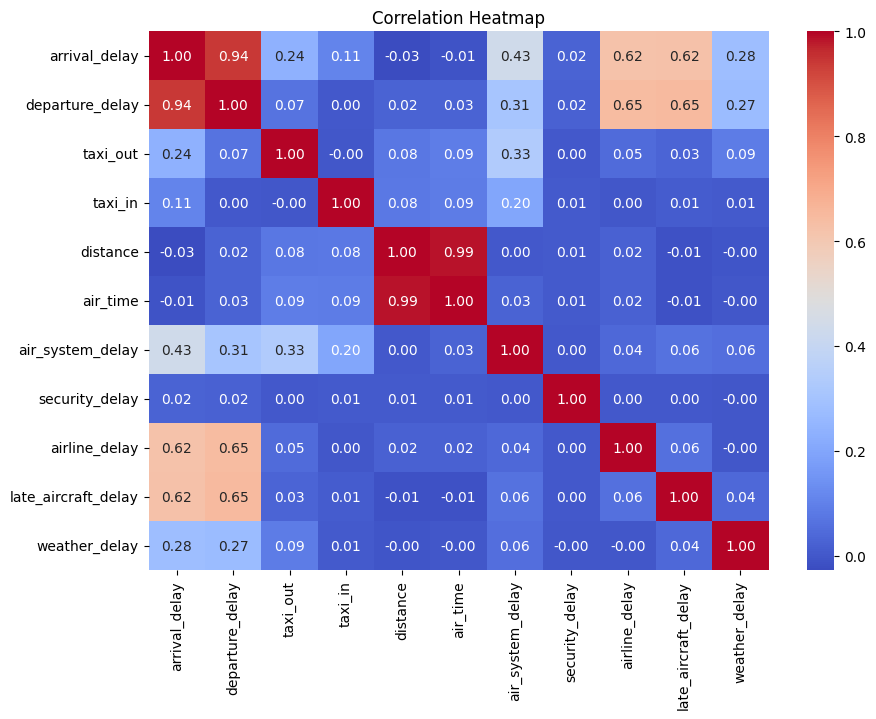

In [19]:
#heatmap of correlation matrix
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
#covariance between the main numeric columns
df[["arrival_delay","departure_delay","distance","air_time"]].cov()

,arrival_delay,departure_delay,distance,air_time
arrival_delay,1425.438493,1251.855675,-647.394092,-22.432932
departure_delay,1251.855675,1257.746906,536.603090,64.331579
distance,-647.394092,536.603090,374407.334170,43833.784391
air_time,-22.432932,64.331579,43833.784391,5264.863710


**Observation:** departure_delay has a very strong positive correlation with arrival_delay (r ≈ 0.94), confirming the Sprint 2 finding that departure punctuality is the biggest driver of arrival punctuality. distance and air_time show almost no correlation with arrival_delay, so flight length is not a major cause of delay.

## 2. Hypothesis Testing

### Test 1: Independent T-Test — WN vs DL Arrival Delay
**Null Hypothesis (H0):** There is no significant difference in average arrival delay between WN and DL.  
**Alternate Hypothesis (H1):** There is a significant difference in average arrival delay between WN and DL.

In [21]:
#taking the two largest airlines by flight volume
wn_delay = df[df["airline"] == "WN"]["arrival_delay"].dropna()
dl_delay = df[df["airline"] == "DL"]["arrival_delay"].dropna()

t_stat, p_value = stats.ttest_ind(wn_delay, dl_delay, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 7.978407149865526
P-Value: 1.5883120138090705e-15


In [22]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 -> There is a significant difference in arrival delay between WN and DL")
else:
    print("Fail to Reject H0 -> No significant difference in arrival delay between WN and DL")

Reject H0 -> There is a significant difference in arrival delay between WN and DL


**Business Interpretation:** The p-value is far below 0.05, so we reject the null hypothesis. WN's average arrival delay (≈4.39 min) is statistically significantly higher than DL's (≈0.26 min). This confirms the difference seen in Sprint 2 is not due to random chance.

### Test 2: Chi-Square Test — Airline vs Cancellation
**Null Hypothesis (H0):** Airline and flight cancellation are independent.  
**Alternate Hypothesis (H1):** Airline and flight cancellation are not independent.

In [23]:
#building a contingency table of airline vs cancelled
contingency_table = pd.crosstab(df["airline"], df["cancelled"])
contingency_table

cancelled,0,1
airline,,
AA,6104,104
AS,1513,2
B6,2280,39
DL,7457,31
EV,4819,150
F9,745,5
HA,674,4
MQ,2428,131
NK,979,11


In [24]:
chi2_stat, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_val_chi)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 390.5313894788322
P-Value: 2.2322980116493114e-75
Degrees of Freedom: 13


In [25]:
if p_val_chi < alpha:
    print("Reject H0 -> Cancellation rate depends on the airline")
else:
    print("Fail to Reject H0 -> Cancellation rate is independent of the airline")

Reject H0 -> Cancellation rate depends on the airline


**Business Interpretation:** The p-value is extremely small, so we reject H0. Cancellation rate is not the same across airlines — this statistically confirms the pattern from Sprint 2 where MQ and EV had much higher cancellation rates than AS and DL.

### Test 3: One-Way ANOVA — Month vs Arrival Delay
**Null Hypothesis (H0):** Average arrival delay is the same across all months.  
**Alternate Hypothesis (H1):** At least one month has a significantly different average arrival delay.

In [26]:
#grouping arrival_delay values month wise
month_groups = [group["arrival_delay"].dropna().values for name, group in df.groupby("month", observed=True)]

f_stat, p_val_anova = stats.f_oneway(*month_groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_val_anova)

F-Statistic: 33.6176673334045
P-Value: 3.0181352875464233e-72


In [27]:
if p_val_anova < alpha:
    print("Reject H0 -> Average arrival delay is significantly different across months")
else:
    print("Fail to Reject H0 -> Average arrival delay does not significantly differ across months")

Reject H0 -> Average arrival delay is significantly different across months


**Business Interpretation:** With such a small p-value, we reject H0. Arrival delay is not consistent throughout the year — this statistically validates the seasonal pattern (February and June being worse months) identified in Sprint 2.

## 3. Confidence Interval Analysis

In [28]:
#95% confidence interval for the mean arrival delay
mean_delay = df["arrival_delay"].mean()
sem_delay = stats.sem(df["arrival_delay"].dropna())

ci_low, ci_high = stats.t.interval(0.95, len(df["arrival_delay"].dropna()) - 1,
                                    loc=mean_delay, scale=sem_delay)

print("Mean Arrival Delay:", mean_delay)
print("95% Confidence Interval:", (ci_low, ci_high))

Mean Arrival Delay: 3.9994499337883265
95% Confidence Interval: (np.float64(3.6654405686436653), np.float64(4.333459298932987))


In [29]:
#95% confidence interval for the mean departure delay
mean_dep = df["departure_delay"].mean()
sem_dep = stats.sem(df["departure_delay"].dropna())

ci_low_dep, ci_high_dep = stats.t.interval(0.95, len(df["departure_delay"].dropna()) - 1,
                                            loc=mean_dep, scale=sem_dep)

print("Mean Departure Delay:", mean_dep)
print("95% Confidence Interval:", (ci_low_dep, ci_high_dep))

Mean Departure Delay: 9.086525571759353
95% Confidence Interval: (np.float64(8.7732526654781), np.float64(9.399798478040605))


**Interpretation:** We are 95% confident that the true average arrival delay for the entire flight network lies between roughly 3.67 and 4.33 minutes. Since this range is fairly narrow (thanks to the large sample size of 50,000 flights), this mean estimate can be treated as reliable for network-level planning, even though individual flights vary a lot.

## 4. Feature Engineering

### Feature 1: Delay Category
Business purpose: converts the raw delay minutes into a simple label that operations teams can use for reporting without reading a number every time.

In [30]:
def delay_category(x):
    if x <= 0:
        return "On Time / Early"
    elif x <= 15:
        return "Minor Delay"
    elif x <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

df["delay_category"] = df["arrival_delay"].apply(delay_category)

df["delay_category"].value_counts()

delay_category
On Time / Early    31227
Minor Delay         9083
Moderate Delay      6165
Severe Delay        3525
Name: count, dtype: int64

### Feature 2: Delay Severity (numeric score)
Business purpose: a numeric version of delay_category so it can be used in later calculations and correlation checks, since the text labels can't be averaged directly.

In [31]:
severity_map = {
    "On Time / Early": 0,
    "Minor Delay": 1,
    "Moderate Delay": 2,
    "Severe Delay": 3
}

df["delay_severity"] = df["delay_category"].map(severity_map)

df["delay_severity"].value_counts()

delay_severity
0    31227
1     9083
2     6165
3     3525
Name: count, dtype: int64

### Feature 3: Flight Distance Category
Business purpose: groups routes into short/medium/long haul so scheduling teams can compare delay patterns by route type instead of by exact distance.

In [32]:
def distance_category(x):
    if x < 500:
        return "Short Haul"
    elif x <= 1500:
        return "Medium Haul"
    else:
        return "Long Haul"

df["distance_category"] = df["distance"].apply(distance_category)

df["distance_category"].value_counts()

distance_category
Medium Haul    24948
Short Haul     18227
Long Haul       6825
Name: count, dtype: int64

### Feature 4: Peak Hour Indicator
Business purpose: flags flights scheduled during the busiest travel hours of the day (6-9 AM and 4-7 PM), which is useful for understanding congestion-driven delay.

In [33]:
#extracting the scheduled hour from scheduled_departure
df["sched_hour"] = pd.to_datetime(df["scheduled_departure"], format="%H:%M:%S").dt.hour

peak_hours = [6,7,8,9,16,17,18,19]

df["peak_hour_flag"] = df["sched_hour"].apply(lambda h: 1 if h in peak_hours else 0)

df["peak_hour_flag"].value_counts()

peak_hour_flag
1    25118
0    24882
Name: count, dtype: int64

In [34]:
df.groupby("peak_hour_flag")["arrival_delay"].mean()

peak_hour_flag
0    4.540484
1    3.462304
Name: arrival_delay, dtype: float64

### Feature 5: Weekend Flight Indicator
Business purpose: separates weekend flights from weekday flights, since Sprint 2 showed weekday travel (Monday, Thursday) had higher average delay than weekends.

In [35]:
df["weekend_flag"] = df["day_of_week"].apply(lambda d: 1 if d in ["Saturday","Sunday"] else 0)

df.groupby("weekend_flag")["arrival_delay"].mean()

weekend_flag
0    4.534750
1    2.513424
Name: arrival_delay, dtype: float64

### Feature 6: Busy Airport Flag
Business purpose: flags flights departing from the 10 busiest origin airports (by flight volume), since high-traffic airports are more prone to congestion delay.

In [36]:
#top 10 busiest origin airports by number of flights
busy_airports = df["origin_airport"].value_counts().head(10).index.tolist()
busy_airports

['ATL', 'ORD', 'DFW', 'LAX', 'DEN', 'PHX', 'SFO', 'IAH', 'LAS', 'MSP']

In [37]:
df["busy_airport_flag"] = df["origin_airport"].apply(lambda a: 1 if a in busy_airports else 0)

df.groupby("busy_airport_flag")["arrival_delay"].mean()

busy_airport_flag
0    3.282534
1    5.418746
Name: arrival_delay, dtype: float64

### Feature 7: Airline Performance Score
Business purpose: a single 0-100 score per airline that combines average delay and cancellation rate, so airlines can be ranked on one metric instead of two separate ones.

In [38]:
#grouping by airline to get avg delay and cancellation rate
airline_stats = df.groupby("airline", observed=True).agg(
    avg_delay=("arrival_delay", "mean"),
    cancel_rate=("cancelled", "mean")
)

#normalizing both columns between 0 and 1
airline_stats["delay_norm"] = (airline_stats["avg_delay"] - airline_stats["avg_delay"].min()) / (airline_stats["avg_delay"].max() - airline_stats["avg_delay"].min())
airline_stats["cancel_norm"] = (airline_stats["cancel_rate"] - airline_stats["cancel_rate"].min()) / (airline_stats["cancel_rate"].max() - airline_stats["cancel_rate"].min())

#lower delay and lower cancellation = higher score. weighting delay more since it affects more passengers
airline_stats["airline_performance_score"] = round(100 * (1 - 0.7*airline_stats["delay_norm"] - 0.3*airline_stats["cancel_norm"]), 2)

airline_stats = airline_stats.sort_values("airline_performance_score", ascending=False)
airline_stats

,avg_delay,cancel_rate,delay_norm,cancel_norm,airline_performance_score
airline,,,,,
AS,-1.172071,0.001320,0.000000,0.000000,100.00
DL,0.258801,0.004140,0.091256,0.056542,91.92
HA,1.084570,0.005900,0.143921,0.091827,87.17
AA,2.253574,0.016753,0.218476,0.309443,75.42
US,2.910349,0.019988,0.260363,0.374322,70.54
WN,4.385050,0.011602,0.354414,0.206174,69.01
UA,4.344868,0.013582,0.351851,0.245867,67.99
VX,7.042831,0.003704,0.523918,0.047794,61.89
OO,5.100737,0.019027,0.400058,0.355041,61.34


In [39]:
#mapping the score back to the main dataframe
df["airline_performance_score"] = df["airline"].map(airline_stats["airline_performance_score"])

### Feature 8: Delay Risk Category
Business purpose: combines delay severity, peak hour, and busy airport into one overall risk label for a flight, which can be used to flag high-risk flights before they even depart.

In [40]:
df["delay_risk_score"] = df["delay_severity"] + df["peak_hour_flag"] + df["busy_airport_flag"]

def risk_category(s):
    if s <= 0:
        return "Low Risk"
    elif s <= 1:
        return "Moderate Risk"
    elif s <= 2:
        return "High Risk"
    else:
        return "Very High Risk"

df["delay_risk_category"] = df["delay_risk_score"].apply(risk_category)

df["delay_risk_category"].value_counts()

delay_risk_category
Moderate Risk     19435
High Risk         11570
Low Risk           9903
Very High Risk     9092
Name: count, dtype: int64

## 5. Feature Evaluation

In [41]:
#checking if delay_risk_category actually separates arrival_delay well
df.groupby("delay_risk_category")["arrival_delay"].agg(["mean","count"]).sort_values("mean")

,mean,count
delay_risk_category,,
Low Risk,-12.137231,9903
Moderate Risk,-9.513455,19435
High Risk,3.224201,11570
Very High Risk,56.756512,8177


In [42]:
#checking if distance_category shows a real difference in delay
df.groupby("distance_category")["arrival_delay"].agg(["mean","count"])

,mean,count
distance_category,,
Long Haul,0.671448,6763
Medium Haul,4.287858,24519
Short Haul,4.866483,17803


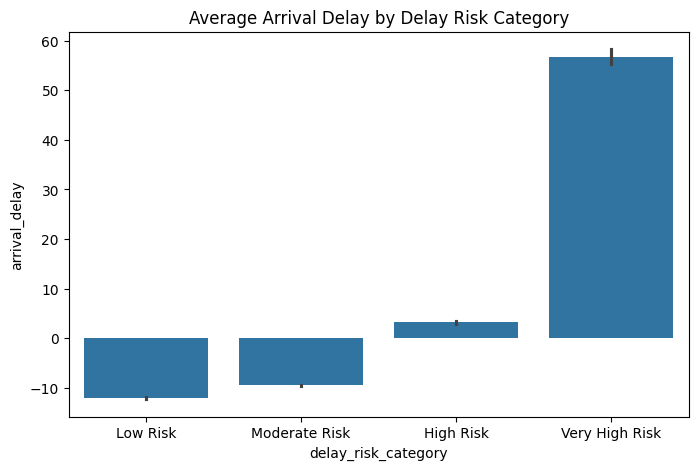

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="delay_risk_category", y="arrival_delay",
            order=["Low Risk","Moderate Risk","High Risk","Very High Risk"])
plt.title("Average Arrival Delay by Delay Risk Category")
plt.show()

**Observation:** The delay_risk_category feature clearly separates flights — average arrival delay climbs from about -12 minutes (Low Risk) to about 57 minutes (Very High Risk). This confirms the engineered feature is adding real predictive value and is not just a random split of the data. distance_category, on the other hand, shows only a small difference between categories, consistent with the earlier finding that distance is not a strong driver of delay.

In [44]:
#saving the feature engineered dataset for future use
df.to_csv("Flight_Delays_Feature_Engineered.csv", index=False)

## 6. Final Business Recommendations

- **Target WN's delay gap statistically confirmed**: the t-test shows WN's higher average arrival delay
  compared to DL is real, not random. WN should be prioritized for an on-time performance improvement plan.
- **Cancellation is airline-specific, not random**: the chi-square test confirms cancellation rate depends
  on the airline. MQ and EV need cancellation-focused root cause reviews, not general delay reviews.
- **Seasonal buffers are statistically justified**: ANOVA confirms delay genuinely varies by month, so
  airlines should apply seasonal scheduling buffers (e.g. in February) instead of one flat buffer all year.
- **Use delay_risk_category for proactive flagging**: since this engineered feature clearly separates high
  and low delay flights, it can be used to flag high-risk flights (peak hour + busy airport + prior severity)
  before departure so ground staff can prioritize turnaround.
- **Use airline_performance_score for internal benchmarking**: this single score makes it easy to rank
  airlines/partners on combined delay and cancellation performance instead of comparing two separate metrics.
- **Distance is confirmed (again) as a non-factor**: distance_category shows only a small delay difference,
  so operational focus should stay on turnaround time and scheduling rather than route length.
